#### Import

In [1]:
import sys
sys.path.insert(0, '..')
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import (
    compute_class_weights, train_with_early_stopping, print_test_evaluation
)
from src.gnn.visualization import plot_learning_curves

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt', undirected=False)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Multi-seed

In [5]:
import numpy as np
import torch
from src.gnn.seed import set_seed
from src.gnn.training import compute_class_weights, train_with_early_stopping, evaluate

seeds = [42, 0, 123]
results = []

for seed in seeds:
    print(f"\n{'='*40}\nRUNNING GRAPHSAGE WITH SEED {seed}\n{'='*40}")
    
    set_seed(seed)

    class GraphSAGE(torch.nn.Module):
        def __init__(self, in_channels, hidden_channels, out_channels, aggregator_type='mean', dropout=0.5):
            super().__init__()
            self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=aggregator_type)
            self.conv2 = SAGEConv(hidden_channels, out_channels, aggr=aggregator_type)
            self.dropout = dropout

        def forward(self, x, edge_index):
            x = self.conv1(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
            x = self.conv2(x, edge_index)
            return x
    
    model = GraphSAGE(
        in_channels=data.x.shape[1],
        hidden_channels=64,
        out_channels=2,
        aggregator_type='mean',
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'../saved_models/graphsage_best_seed_{seed}.pt'
    history = train_with_early_stopping(
        model, data, optimizer, criterion,
        save_path=save_path,
        num_epochs=200,
        patience=20,
        monitor_metric='f1_ill',
    )
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    test_metrics = evaluate(model, data, criterion, data.test_mask)
    
    results.append({
        'seed': seed,
        'f1_ill': test_metrics['f1_ill'],
        'precision': test_metrics['precision_ill'],
        'recall': test_metrics['recall_ill'],
        'auc_pr': test_metrics['auc_pr']
    })

f1_ill_list = [res['f1_ill'] for res in results]
precision_list = [res['precision'] for res in results]
recall_list = [res['recall'] for res in results]
auc_pr_list = [res['auc_pr'] for res in results]

print(f"\n{'='*40}\nFINAL GRAPHSAGE MULTI-SEED RESULTS\n{'='*40}")
print(f"F1(illicit): {np.mean(f1_ill_list):.4f} ± {np.std(f1_ill_list):.4f}")
print(f"Precision  : {np.mean(precision_list):.4f} ± {np.std(precision_list):.4f}")
print(f"Recall     : {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"AUC-PR     : {np.mean(auc_pr_list):.4f} ± {np.std(auc_pr_list):.4f}")



RUNNING GRAPHSAGE WITH SEED 42
Class weights: licit=1.00, illicit=2.86
Epoch 001: Train Loss=0.6881, Train F1=0.4850, Val F1=0.4384, Gap=0.0466
Epoch 002: Train Loss=0.4359, Train F1=0.5835, Val F1=0.5215, Gap=0.0620
Epoch 003: Train Loss=0.3645, Train F1=0.6303, Val F1=0.5651, Gap=0.0652
Epoch 004: Train Loss=0.3306, Train F1=0.6600, Val F1=0.5741, Gap=0.0859
Epoch 005: Train Loss=0.3111, Train F1=0.6729, Val F1=0.5656, Gap=0.1073
Epoch 006: Train Loss=0.2854, Train F1=0.6718, Val F1=0.5633, Gap=0.1085
Epoch 007: Train Loss=0.2693, Train F1=0.6830, Val F1=0.5698, Gap=0.1131
Epoch 008: Train Loss=0.2592, Train F1=0.7050, Val F1=0.5922, Gap=0.1128
Epoch 009: Train Loss=0.2509, Train F1=0.7278, Val F1=0.6315, Gap=0.0963
Epoch 010: Train Loss=0.2386, Train F1=0.7464, Val F1=0.6393, Gap=0.1070
Epoch 011: Train Loss=0.2308, Train F1=0.7502, Val F1=0.6413, Gap=0.1089
Epoch 012: Train Loss=0.2264, Train F1=0.7502, Val F1=0.6312, Gap=0.1190
Epoch 013: Train Loss=0.2155, Train F1=0.7542, Val F

#### Define model

2-layer Graph Convolutional Network (GCN) structure:

In [4]:
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, aggregator_type='mean', dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr=aggregator_type)
        self.conv2 = SAGEConv(hidden_channels, out_channels, aggr=aggregator_type)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        return x

model = GraphSAGE(
    in_channels=data.x.shape[1],
    hidden_channels=64,
    out_channels=2,
    aggregator_type='mean',  # mean, gcn, max, lstm
    dropout=0.5
).to(device)

print(model)
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

GraphSAGE(
  (conv1): SAGEConv(165, 64, aggr=mean)
  (conv2): SAGEConv(64, 2, aggr=mean)
)
Number of parameters: 21,442


#### Optimizer, loss, class weights

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
weight = compute_class_weights(data, device)
criterion = torch.nn.CrossEntropyLoss(weight=weight)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [6]:
history = train_with_early_stopping(
    model, data, optimizer, criterion,
    save_path='../saved_models/graphsage_best.pt',
    num_epochs=200,
    patience=20,
)

Epoch 001: Train Loss=0.6881, Train F1=0.4850, Val F1=0.4384, Gap=0.0466
Epoch 002: Train Loss=0.4359, Train F1=0.5835, Val F1=0.5215, Gap=0.0620
Epoch 003: Train Loss=0.3645, Train F1=0.6303, Val F1=0.5651, Gap=0.0652
Epoch 004: Train Loss=0.3306, Train F1=0.6600, Val F1=0.5741, Gap=0.0859
Epoch 005: Train Loss=0.3111, Train F1=0.6729, Val F1=0.5656, Gap=0.1073
Epoch 006: Train Loss=0.2854, Train F1=0.6718, Val F1=0.5633, Gap=0.1085
Epoch 007: Train Loss=0.2693, Train F1=0.6830, Val F1=0.5698, Gap=0.1131
Epoch 008: Train Loss=0.2592, Train F1=0.7050, Val F1=0.5922, Gap=0.1128
Epoch 009: Train Loss=0.2509, Train F1=0.7278, Val F1=0.6315, Gap=0.0963
Epoch 010: Train Loss=0.2386, Train F1=0.7464, Val F1=0.6393, Gap=0.1070
Epoch 011: Train Loss=0.2308, Train F1=0.7502, Val F1=0.6413, Gap=0.1089
Epoch 012: Train Loss=0.2264, Train F1=0.7502, Val F1=0.6312, Gap=0.1190
Epoch 013: Train Loss=0.2155, Train F1=0.7542, Val F1=0.6327, Gap=0.1215
Epoch 014: Train Loss=0.2021, Train F1=0.7697, Val 

#### Learning curve

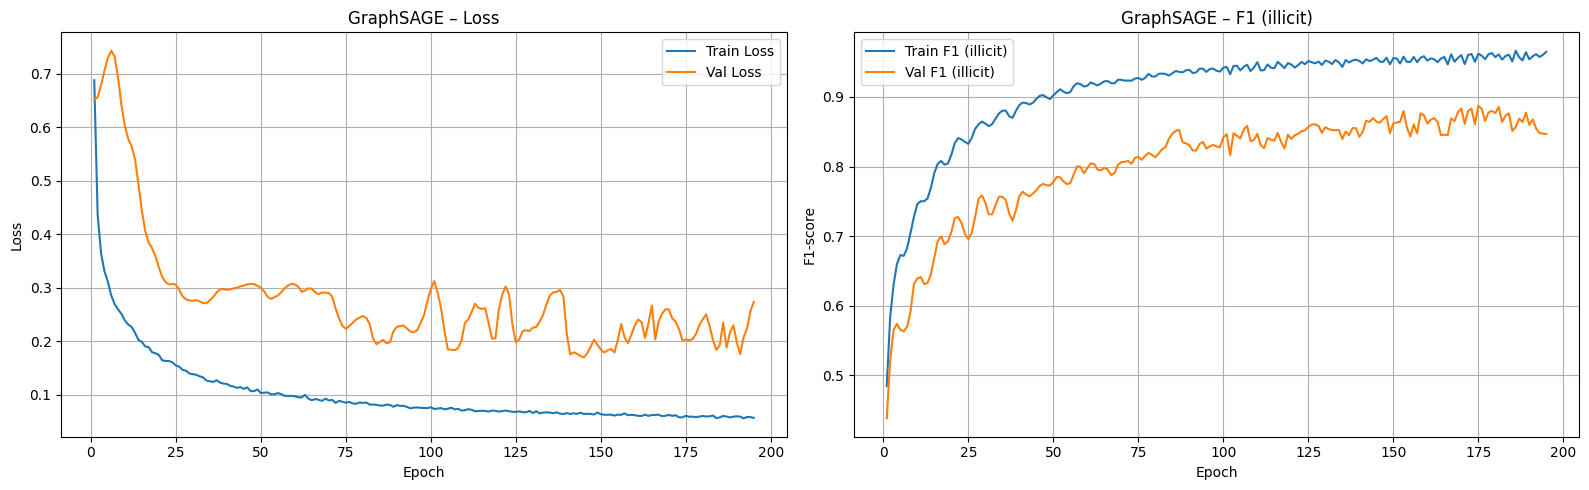

In [7]:
plot_learning_curves(history, model_name="GraphSAGE")

#### Test evaluation

In [8]:
model.load_state_dict(torch.load('../saved_models/graphsage_best.pt'))
print_test_evaluation(model, data, criterion, label="GraphSAGE Test")

 GraphSAGE Test Set Evaluation
  Loss          : 0.6006
  Accuracy      : 0.9344
  Precision(ill): 0.4961
  Recall(ill)   : 0.6427
  F1(illicit)   : 0.5599
  F1(macro)     : 0.7622
  AUC-PR        : 0.5723

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9747    0.9546    0.9645     15587
 Illicit (1)     0.4961    0.6427    0.5599      1083

    accuracy                         0.9344     16670
   macro avg     0.7354    0.7987    0.7622     16670
weighted avg     0.9436    0.9344    0.9383     16670

Confusion Matrix:
[[14880   707]
 [  387   696]]
